In [5]:
import pandas as pd
import numpy as np

data = {
    "Order_ID": [201,202,203,204,205,206,207,208,209,210],
    "Customer": ["A","B","A","C","B","A","D","E","D","A"],
    "Product": ["Laptop","Phone","Tablet","Laptop","Phone","Tablet","Laptop","Phone","Tablet","Laptop"],
    "Price": [800,500,300,850,520,310,800,500,300,800],
    "Quantity": [1,2,1,1,3,2,1,2,1,np.nan]
}

df = pd.DataFrame(data)
df

,Order_ID,Customer,Product,Price,Quantity
0,201,A,Laptop,800,1.0
1,202,B,Phone,500,2.0
2,203,A,Tablet,300,1.0
3,204,C,Laptop,850,1.0
4,205,B,Phone,520,3.0
5,206,A,Tablet,310,2.0
6,207,D,Laptop,800,1.0
7,208,E,Phone,500,2.0
8,209,D,Tablet,300,1.0
9,210,A,Laptop,800,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Order_ID  10 non-null     int64  
 1   Customer  10 non-null     object 
 2   Product   10 non-null     object 
 3   Price     10 non-null     int64  
 4   Quantity  9 non-null      float64
dtypes: float64(1), int64(2), object(2)
memory usage: 392.0+ bytes


In [4]:
df.describe()

,Order_ID,Price,Quantity
count,10.00000,10.000000,9.000000
mean,205.50000,568.000000,1.555556
std,3.02765,226.754885,0.726483
min,201.00000,300.000000,1.000000
25%,203.25000,357.500000,1.000000
50%,205.50000,510.000000,1.000000
75%,207.75000,800.000000,2.000000
max,210.00000,850.000000,3.000000


In [11]:
df['Quantity'].fillna(df['Quantity'].median(),inplace=True)
#df 
'''mean is calculated because there is no outliers ever points are around 1 to 3 there 
is no large change median can also be use get the round value median is used'''

In [12]:
#Feature Engineering
df['Total'] = df['Price'] * df['Quantity']

In [14]:
# Top 3 customers contributing to revenue
df.groupby('Customer')['Total'].sum().sort_values(ascending=False).head(3)


Customer
A    2964.444444
B    2560.000000
D    1100.000000
Name: Total, dtype: float64

In [21]:
# Find top product (highest spending)
df.groupby('Product')['Total'].sum().idxmax()

'Laptop'

In [18]:
# Find least contributing customers (bottom 20%)
# df.groupby('Customer')['Total'].sum().idxmax() (idxmax() gives the highest value here need to find the least)

'A'

In [20]:
# Most profitable product
df.groupby('Product')['Total'].sum().idxmax()

'Laptop'

In [ ]:
# Customer Segmentation '''High (top 30%),Medium (next 50%),Low (bottom 20%)'''
add = df
def seg(x):
    if x > 

In [23]:
#Pareto chart
customer_revenue = df.groupby('Customer')['Total'].sum().sort_values(ascending=False)
print(customer_revenue)

Customer
A    2964.444444
B    2560.000000
D    1100.000000
E    1000.000000
C     850.000000
Name: Total, dtype: float64


In [25]:
cum_sum = customer_revenue.cumsum()
print(cum_sum)

Customer
A    2964.444444
B    5524.444444
D    6624.444444
E    7624.444444
C    8474.444444
Name: Total, dtype: float64


In [26]:
cum_perc = cum_sum / customer_revenue.sum() * 100
print(cum_perc)

Customer
A     34.980989
B     65.189459
D     78.169660
E     89.969844
C    100.000000
Name: Total, dtype: float64


In [27]:
pareto_df = pd.DataFrame({
    'Revenue': customer_revenue,
    'Cum_Percentage': cum_perc
})

In [29]:
top_80 = pareto_df[pareto_df['Cum_Percentage'] <= 80]
print(top_80)
bottom_20 = pareto_df[pareto_df['Cum_Percentage'] > 80]
print(bottom_20)

              Revenue  Cum_Percentage
Customer                             
A         2964.444444       34.980989
B         2560.000000       65.189459
D         1100.000000       78.169660
          Revenue  Cum_Percentage
Customer                         
E          1000.0       89.969844
C           850.0      100.000000


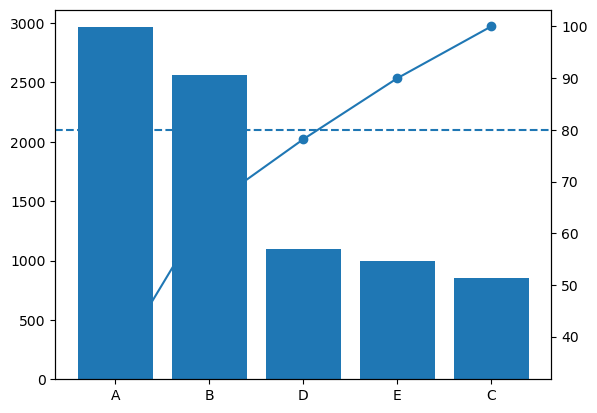

In [30]:
#Pareto Chart
import matplotlib.pyplot as plt

pareto_df = pareto_df.reset_index()

fig, ax = plt.subplots()

# Bar chart
ax.bar(pareto_df['Customer'], pareto_df['Revenue'])

# Line chart
ax2 = ax.twinx()
ax2.plot(pareto_df['Customer'], pareto_df['Cum_Percentage'], marker='o')

# 80% line
ax2.axhline(80, linestyle='--')

plt.show()